<a href="https://colab.research.google.com/github/radomskia/desktop/blob/avoid-flickering-compare/analiza_film%C3%B3w_polskich.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup

def get_imdb_genres():
    # Send a GET request to the IMDb genres page
    response = requests.get("https://www.imdb.com/genres/movie")

    # Parse the HTML content
    soup = BeautifulSoup(response.content, "html.parser")

    # Extract the genre names from the HTML content
    genre_elements = soup.find_all("div", class_="lister-item mode-advanced")
    genre_names = [
        element.find("a").text.strip() for element in genre_elements
    ]

    return genre_names

# Print the list of IMDb genres
imdb_genres = get_imdb_genres()
print(imdb_genres)


[]


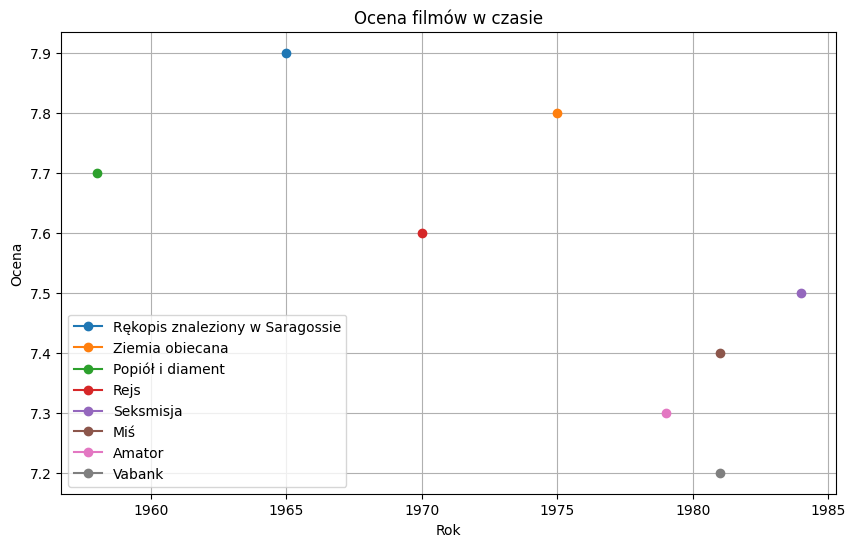

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Przykładowe dane
data = {
    'Tytuł': ['Rękopis znaleziony w Saragossie', 'Ziemia obiecana', 'Popiół i diament', 'Rejs', 'Seksmisja', 'Miś', 'Amator', 'Vabank'],
    'Rok': [1965, 1975, 1958, 1970, 1984, 1981, 1979, 1981],
    'Ocena': [7.9, 7.8, 7.7, 7.6, 7.5, 7.4, 7.3, 7.2]  # Przykładowe oceny
}

df = pd.DataFrame(data)

# Tworzenie wykresu
plt.figure(figsize=(10,6))
for title in df['Tytuł'].unique():
    movie_data = df[df['Tytuł'] == title]
    plt.plot(movie_data['Rok'], movie_data['Ocena'], marker='o', label=title)

plt.xlabel('Rok')
plt.ylabel('Ocena')
plt.title('Ocena filmów w czasie')
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
import requests
from bs4 import BeautifulSoup

def get_polish_movies_by_genre():
    url = "https://www.imdb.com/search/title/?countries=pl&sort=year,desc"
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        movies = soup.find_all('div', class_='lister-item-content')

        genre_count = {}

        for movie in movies:
            title = movie.find('h3').find('a').text
            year = movie.find('span', class_='lister-item-year').text.strip('()')
            genre = movie.find('span', class_='genre').text.strip()

            # Dodajemy do słownika kategorii filmowych
            if genre in genre_count:
                genre_count[genre] += 1
            else:
                genre_count[genre] = 1

            print(f"{title} ({year}) - {genre}")

        # Wyświetlamy liczbę filmów w poszczególnych kategoriach
        print("\nLiczba filmów w poszczególnych kategoriach:")
        for genre, count in genre_count.items():
            print(f"{genre}: {count}")

    else:
        print(f"Failed to retrieve data. Status code: {response.status_code}")

if __name__ == "__main__":
    get_polish_movies_by_genre()


Failed to retrieve data. Status code: 403


In [ ]:
import requests
from bs4 import BeautifulSoup

def get_top_rated_polish_movies():
    url = "https://www.imdb.com/search/title/?countries=pl&sort=user_rating,desc"
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        movies = soup.find_all('div', class_='lister-item-content')[:10]

        for idx, movie in enumerate(movies, start=1):
            title = movie.find('h3').find('a').text
            year = movie.find('span', class_='lister-item-year').text.strip('()')
            rating = movie.find('div', class_='ratings-imdb-rating').text.strip()

            print(f"{idx}. {title} ({year}) - Rating: {rating}")

    else:
        print(f"Failed to retrieve data. Status code: {response.status_code}")

if __name__ == "__main__":
    get_top_rated_polish_movies()


Failed to retrieve data. Status code: 403


Failed to retrieve data. Status code: 403
Failed to retrieve data. Status code: 403


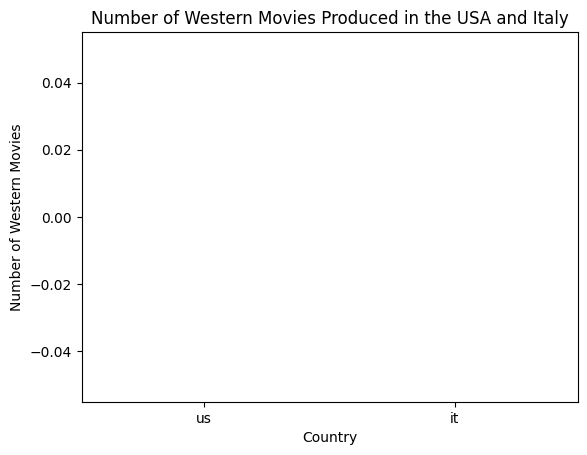

In [ ]:
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

def get_movie_count_by_country_and_genre(country, genre):
    url = f"https://www.imdb.com/search/title/?countries={country}&genres={genre}&sort=year,desc"
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.text, 'html.parser')
        movies = soup.find_all('div', class_='lister-item-content')

        return len(movies)

    else:
        print(f"Failed to retrieve data. Status code: {response.status_code}")
        return 0

def visualize_movie_counts():
    countries = ['us', 'it']
    genres = 'western'

    counts = [get_movie_count_by_country_and_genre(country, genres) for country in countries]

    plt.bar(countries, counts, color=['blue', 'green'])
    plt.xlabel('Country')
    plt.ylabel('Number of Western Movies')
    plt.title('Number of Western Movies Produced in the USA and Italy')
    plt.show()

if __name__ == "__main__":
    visualize_movie_counts()


In [ ]:
import requests

def get_top_rated_westerns():
    # Wstaw swój klucz API IMDb
    api_key = 'TWÓJ_KLUCZ_API_IMDB'

    # Utwórz zapytanie do API IMDb dla najwyżej ocenianych westernów
    url = f'https://imdb-api.com/en/API/Top250Movies/{api_key}'

    try:
        response = requests.get(url)
        data = response.json()

        # Wyodrębnij informacje o westernach (możesz dostosować to do własnych potrzeb)
        westerns = [movie for movie in data['items'] if 'Western' in movie.get('genres', '')]

        # Zwróć 10 najwyżej ocenianych westernów
        return westerns[:10]

    except requests.exceptions.RequestException as e:
        print(f'Błąd podczas pobierania danych: {e}')

if __name__ == "__main__":
    top_westerns = get_top_rated_westerns()

    # Wyświetl wyniki
    if top_westerns:
        print("10 najwyżej ocenianych westernów:")
        for idx, movie in enumerate(top_westerns, start=1):
            print(f"{idx}. {movie['title']} ({movie['year']}) - Ocena: {movie['rank']}")
    else:
        print("Nie udało się pobrać danych.")


Nie udało się pobrać danych.


In [ ]:
import requests

def get_movie_details(title):
    # Wstaw swój klucz API IMDb
    api_key = 'TWÓJ_KLUCZ_API_IMDB'

    # Utwórz zapytanie do API IMDb dla filmu o podanym tytule
    url = f'https://imdb-api.com/en/API/Search/{api_key}/{title}'

    try:
        response = requests.get(url)
        data = response.json()

        # Sprawdź, czy znaleziono film o podanym tytule
        if data['results']:
            movie_id = data['results'][0]['id']
            movie_details_url = f'https://imdb-api.com/en/API/Title/{api_key}/{movie_id}'

            # Pobierz szczegóły filmu
            movie_details_response = requests.get(movie_details_url)
            movie_details = movie_details_response.json()

            # Wyodrębnij interesujące informacje
            year = movie_details.get('year', '')
            country = movie_details.get('countries', [''])[0]
            director = movie_details.get('directors', [''])[0]
            genres = movie_details.get('genres', [])
            writers = movie_details.get('writers', [])
            actors = movie_details.get('stars', [])
            rating = movie_details.get('imDbRating', '')

            return {
                'Year': year,
                'Country': country,
                'Director': director,
                'Genres': genres,
                'Writers': writers,
                'Actors': actors,
                'Rating': rating
            }
        else:
            return None

    except requests.exceptions.RequestException as e:
        print(f'Błąd podczas pobierania danych: {e}')

if __name__ == "__main__":
    movie_title = 'Gladiator'
    movie_details = get_movie_details(movie_title)

    # Wyświetl wyniki
    if movie_details:
        print(f"Details for the movie '{movie_title}':")
        for key, value in movie_details.items():
            print(f"{key}: {value}")
    else:
        print(f"Nie udało się znaleźć informacji o filmie '{movie_title}'.")


In [ ]:
import requests
from bs4 import BeautifulSoup

# URL of the movie page
url = "https://www.imdb.com/title/tt0172495/"

# Send a GET request to the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse the HTML content
    soup = BeautifulSoup(response.content, 'html.parser')

    # Extract the movie information
    movie_info = soup.find('div', id='titleDetails')

    # Year
    year = movie_info.find('span', id='releaseYear').text.strip()

    # Country
    country = movie_info.find('div', class_='country-of-origin').text.strip()

    # Director
    director = soup.find('div', id='directors').find('a').text.strip()

    # Writers
    writers = []
    for writer in soup.find_all('div', class_='credit_summary_item'):
        writer_name = writer.find('a').text.strip()
        writers.append(writer_name)

    # Genre
    genre = soup.find('div', class_='subtext genres').find('span').text.strip()

    # Runtime
    runtime = soup.find('div', class_='subtext').find('span', class_='runtime').text.strip()

    # Actors
    actors = []
    for actor in soup.find_all('div', class_='credit_summary_item'):
        actor_name = actor.find('a').text.strip()
        actors.append(actor_name)

    # Print the movie information
    print("Movie Information:")
    print("Title:", soup.find('h1', id='h1_heading').text.strip())
    print("Year:", year)
    print("Country:", country)
    print("Director:", director)
    print("Writers:", ", ".join(writers))
    print("Genre:", genre)
    print("Runtime:", runtime)
    print("Actors:", ", ".join(actors))
else:
    print("Error: Unable to scrape the movie information.")






Error: Unable to scrape the movie information.


In [ ]:
import requests
from bs4 import BeautifulSoup

# Define the URL of the Filmweb ranking page for westerns
url = "https://www.filmweb.pl/ranking/film/genre/25"

# Send a GET request to the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse the HTML content of the response
    soup = BeautifulSoup(response.content, 'html.parser')

    # Extract the list of western movies
    movies = soup.find_all('div', class_='film')

    # Filter movies by production country (Poland)
    polish_westerns = []
    for movie in movies:
        country_element = movie.find('span', class_='country')
        if country_element and country_element.text.strip() == 'Polska':
            polish_westerns.append(movie)

    # Display the titles of Polish western movies
    for movie in polish_westerns:
        title_element = movie.find('a', class_='filmTitle')
        title = title_element.text.strip()
        print(title)
else:
    print("Error fetching the ranking page")


In [ ]:
import requests
from bs4 import BeautifulSoup

# Send a GET request to FilmWeb to retrieve the list of top-rated movies
response = requests.get('https://www.filmweb.pl/ranking/film')

# Parse the HTML content
soup = BeautifulSoup(response.content, 'html.parser')

# Extract movie titles from the ranking page
movie_titles = []
for movie_item in soup.find_all('li', class_='filmListItem'):
    movie_title = movie_item.find('a', class_='film-poster__title').text.strip()
    movie_titles.append(movie_title)

# Display the top 10 movies
print('Top 10 Movies on FilmWeb:')
for i, movie_title in enumerate(movie_titles[:10]):
    print(f'{i+1}. {movie_title}')











Top 10 Movies on FilmWeb:


ERROR: unknown command "insatll" - maybe you meant "install"
             tconst  averageRating  numVotes
843766    tt1996993           10.0        40
732535   tt15501132           10.0        15
1123160   tt4743108           10.0         5
1045665   tt3511834           10.0        19
1190292   tt5845820           10.0         6
1045666   tt3511836           10.0        19
974709   tt27490757           10.0         5
1045667   tt3511842           10.0        19
732534   tt15501130           10.0        15
1045668   tt3511844           10.0        20


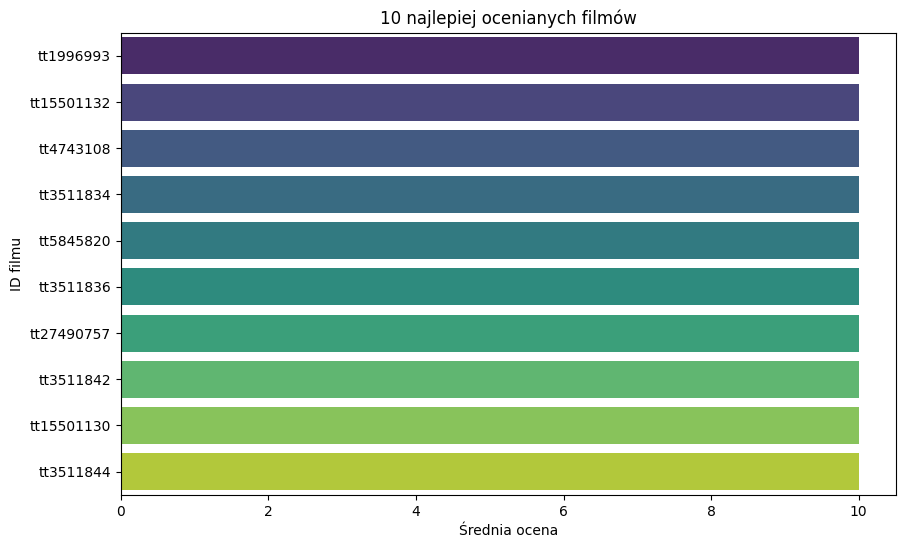

In [ ]:
! pip install pandas
! pip insatll matplotlib
! pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytaj dane
df = pd.read_csv('title.ratings.tsv', sep='\t')

# Posortuj filmy według średniej oceny i wybierz 10 najlepszych
top_movies = df.sort_values('averageRating', ascending=False).head(10)

# Wydrukuj 10 najlepszych filmów
print(top_movies)

# Utwórz wykres
plt.figure(figsize=(10,6))
sns.barplot(x='averageRating', y='tconst', data=top_movies, palette='viridis')
plt.xlabel('Średnia ocena')
plt.ylabel('ID filmu')
plt.title('10 najlepiej ocenianych filmów')
plt.show()


In [ ]:
! pip install pandas
! pip install matplotlib

In [ ]:
! pip install pandas
! pip install matplotlib

import pandas as pd

# Wczytaj plik
df = pd.read_csv('title.rating.tsv', sep='\t')

# Wybierz filmy z co najmniej 1000 głosów
df = df[df['numVotes'] > 1000]

# Posortuj filmy według średniej oceny
df = df.sort_values('averageRating', ascending=False)

# Wyświetl 10 najlepiej ocenianych filmów
print(df.head(10))
















             tconst  averageRating  numVotes
911864    tt2301451           10.0    209023
1095274   tt4283088            9.9    220942
911866    tt2301455            9.9    135568
565716    tt1204265            9.9     14716
357580    tt0701989            9.9     11667
1355897   tt9313978            9.9     17531
1095276   tt4283094            9.9    157310
510937   tt11028174            9.9     20271
773396    tt1683088            9.9     72188
868609   tt21151974            9.9     33926


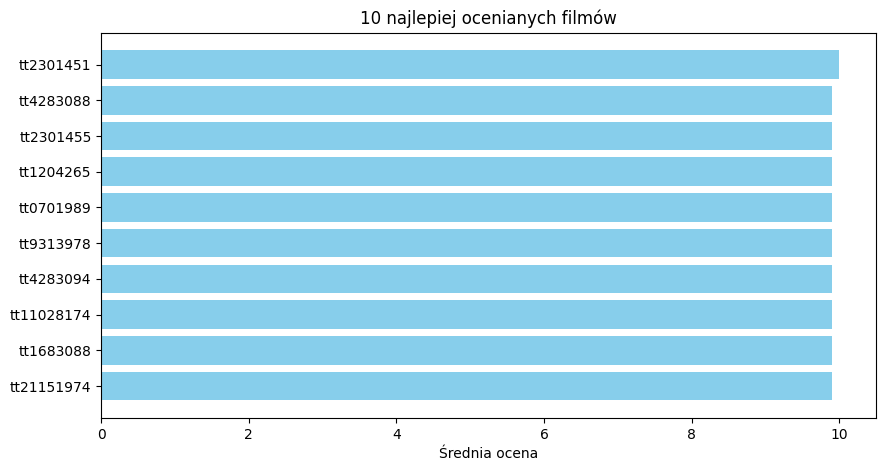

In [ ]:
import matplotlib.pyplot as plt

# Wybierz 10 najlepiej ocenianych filmów
top_movies = df.head(10)

# Utwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_movies['tconst'], top_movies['averageRating'], color='skyblue')
plt.xlabel('Średnia ocena')
plt.title('10 najlepiej ocenianych filmów')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
import pandas as pd

# Wczytaj pliki
ratings = pd.read_csv('title.rating.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz oba ramki danych na podstawie 'tconst'
merged = pd.merge(ratings, basics, on='tconst')

# Wyświetl identyfikator tytułu i nazwę filmu
print(merged[['tconst', 'primaryTitle']])



           tconst            primaryTitle
0       tt0000001              Carmencita
1       tt0000002  Le clown et ses chiens
2       tt0000003          Pauvre Pierrot
3       tt0000004             Un bon bock
4       tt0000005        Blacksmith Scene
...           ...                     ...
420275  tt0876729             Battle Gear
420276  tt0876730                 Cannons
420277  tt0876732         Hardware Stores
420278  tt0876733            Nuclear Subs
420279  tt0876735           The Colosseum

[420280 rows x 2 columns]


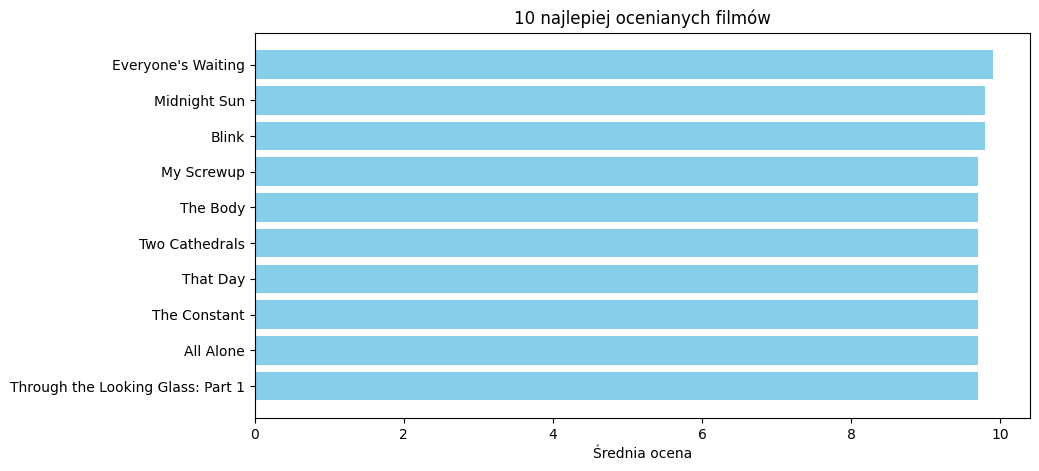

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj pliki
rating = pd.read_csv('title.rating.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz oba ramki danych na podstawie 'tconst'
merged = pd.merge(ratings, basics, on='tconst')

# Wybierz filmy z co najmniej 1000 głosów
merged = merged[merged['numVotes'] > 1000]

# Posortuj filmy według średniej oceny
merged = merged.sort_values('averageRating', ascending=False)

# Wybierz 10 najlepiej ocenianych filmów
top_movies = merged.head(10)

# Utwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_movies['primaryTitle'], top_movies['averageRating'], color='skyblue')
plt.xlabel('Średnia ocena')
plt.title('10 najlepiej ocenianych filmów')
plt.gca().invert_yaxis()
plt.show()





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj pliki
rating = pd.read_csv('title.rating.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz oba ramki danych na podstawie 'tconst'
merged = pd.merge(rating, basics, on='tconst')



In [ ]:
basics = pd.read_csv('title.basics.tsv', sep='\t', low_memory=False)
print(basics.columns)


Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres'],
      dtype='object')


In [ ]:
import pandas as pd

# Wczytaj oba pliki
basics = pd.read_csv('title.basics.tsv', sep='\t', low_memory=False)
akas = pd.read_csv('title.akas.tsv', sep='\t', low_memory=False, error_bad_lines=False)

# Dołącz oba pliki
merged = pd.merge(basics, akas, on='tconst')

# Filtruj do pełnometrażowych filmów z USA
us_movies = merged[(merged['titleType'] == 'movie') & (merged['region'] == 'US')]

# Sortuj według oceny i wyświetl 10 najlepiej ocenianych
top_rated = us_movies.sort_values('averageRating', ascending=False).head(10)
print(top_rated)




<ipython-input-2-82d2f0ed8f8a>:9: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  basics = pd.read_csv('title.basics.tsv', sep='\t')


           tconst  averageRating  numVotes titleType  \
254916  tt0476060            9.6         6     short   
238526  tt0434036            9.3         9     short   
163328  tt0268550            9.3        12     short   
244409  tt0448753            9.2        15   tvMovie   
225728  tt0403903            9.1         8   tvMovie   
158888  tt0259437            9.1        36  tvSeries   
1091    tt0002434            9.0        13     short   
44551   tt0066711            9.0        11  tvSeries   
211706  tt0373454            9.0         7     short   
111819  tt0161627            9.0        13     video   

                             primaryTitle                      originalTitle  \
254916  The Good, the Bad and the Chorley  The Good, the Bad and the Chorley   
238526            A Fistful of Confidence            A Fistful of Confidence   
163328                     The Prospector                     The Prospector   
244409           Ein Sheriff für den Sarg           Ein Sheriff

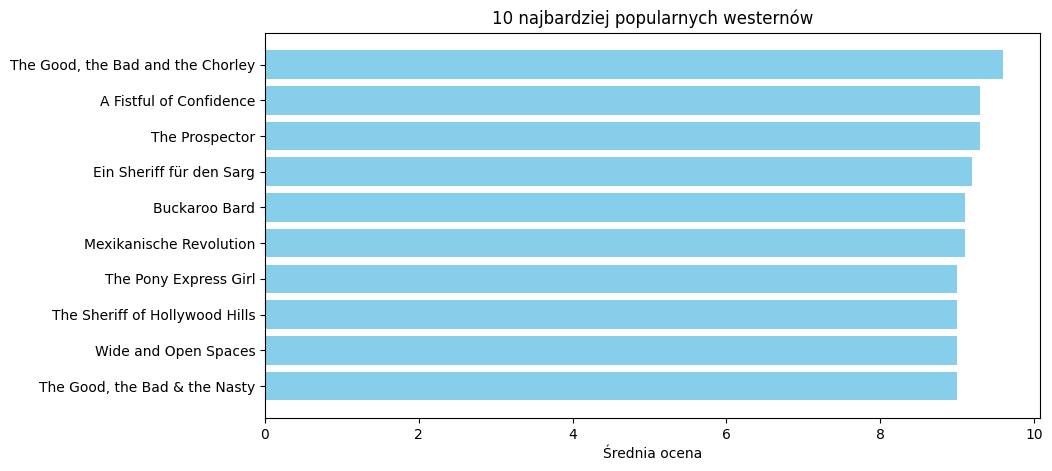

In [ ]:
! pip install pandas
! pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
ratings = pd.read_csv('title.ratings.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz dwa ramki danych
df = pd.merge(ratings, basics, on='tconst')

# Wybierz tylko filmy z gatunku 'Western'
df_western = df[df['genres'].str.contains('Western')]

# Posortuj filmy według oceny i wybierz 10 z najwyższą oceną
top_10_western = df_western.sort_values(by='averageRating', ascending=False).head(10)

# Wyświetl 10 najbardziej popularnych westernów
print(top_10_western)

# Stwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_10_western['primaryTitle'], top_10_western['averageRating'], color='skyblue')
plt.xlabel('Średnia ocena')
plt.title('10 najbardziej popularnych westernów')
plt.gca().invert_yaxis()
plt.show()



           tconst  averageRating  numVotes titleType  \
95861   tt0130281            8.9        15     movie   
167800  tt0277447            8.9         9     movie   
38957   tt0060196            8.8    795741     movie   
170385  tt0282132            8.8        12     movie   
42306   tt0064116            8.5    343880     movie   
93922   tt0126296            8.5        51     movie   
186788  tt0314360            8.4        16     movie   
122716  tt0182787            8.4        12     movie   
22471   tt0040897            8.2    130540     movie   
38417   tt0059578            8.2    269195     movie   

                            primaryTitle                     originalTitle  \
95861                    Stallion Canyon                   Stallion Canyon   
167800                   Yo, el valiente                   Yo, el valiente   
38957     The Good, the Bad and the Ugly   Il buono, il brutto, il cattivo   
170385                         Río Hondo                         Río Ho

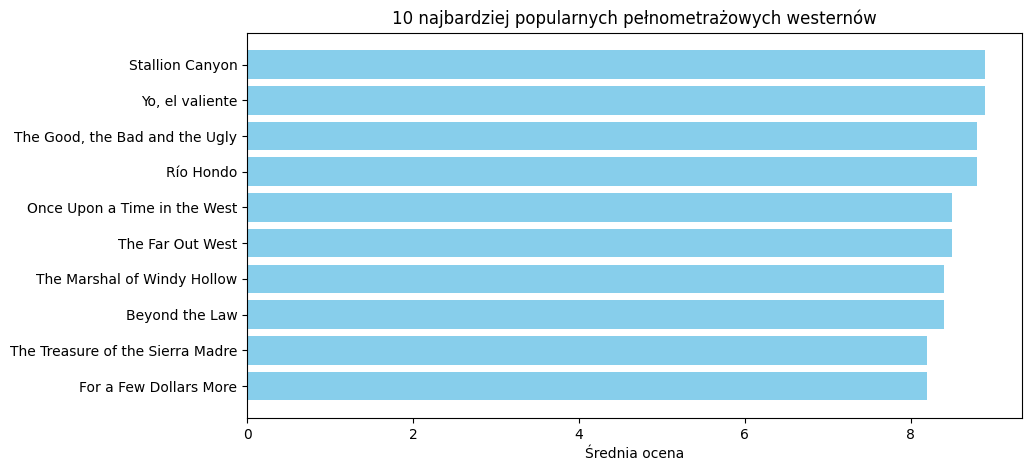

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
ratings = pd.read_csv('title.ratings.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz dwa ramki danych
df = pd.merge(ratings, basics, on='tconst')

# Wybierz tylko filmy pełnometrażowe z gatunku 'Western'
df_western = df[(df['genres'].str.contains('Western')) & (df['titleType'] == 'movie')]

# Posortuj filmy według oceny i wybierz 10 z najwyższą oceną
top_10_western = df_western.sort_values(by='averageRating', ascending=False).head(10)

# Wyświetl 10 najbardziej popularnych westernów
print(top_10_western)

# Stwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_10_western['primaryTitle'], top_10_western['averageRating'], color='skyblue')
plt.xlabel('Średnia ocena')
plt.title('10 najbardziej popularnych pełnometrażowych westernów')
plt.gca().invert_yaxis()
plt.show()




In [ ]:

# zaimportuj potrzebne biblioteki
import pandas as pd
import matplotlib.pyplot as plt

# załaduj swoje ramki danych
ratings = pd.read_csv('ratings.csv')
basics = pd.read_csv('basics.csv')
akas_usa = pd.read_csv('akas_usa.csv')

# połącz trzy ramki danych
df = pd.merge(pd.merge(ratings, basics, on='tconst'), akas_usa, on='tconst')

# wybierz tylko filmy pełnometrażowe z USA
df = df[(df['titleType'] == 'movie') & (df['region'] == 'US')]

# posortuj filmy według oceny i wybierz 10 najlepszych
top10 = df.sort_values('averageRating', ascending=False).head(10)

# wyświetl 10 najlepszych filmów
print(top10[['primaryTitle', 'startYear', 'averageRating']])

# stwórz wykres
plt.figure(figsize=(10, 6))
plt.barh(top10['primaryTitle'], top10['averageRating'], color='skyblue')
plt.xlabel('Average Rating')
plt.title('Top 10 Rated Movies in IMDb')
plt.gca().invert_yaxis()
plt.show()






In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# wczytaj dane z plików
basics = pd.read_csv('title.basics.tsv', sep='\t')
ratings = pd.read_csv('title.ratings.tsv', sep='\t')
akas = pd.read_csv('title.akas.tsv', sep='\t')

# połącz dane
data = pd.merge(basics, ratings, on='tconst')
data = pd.merge(data, akas, on='titleId')

# wybierz tylko filmy pełnometrażowe
data = data[data['titleType'] == 'movie']

# posortuj filmy według oceny i wybierz 10 najlepszych
top_movies = data.sort_values('averageRating', ascending=False).head(10)

# wyświetl listę 10 najpopularniejszych filmów pełnometrażowych
print(top_movies[['primaryTitle', 'averageRating']])

# utwórz wykres
plt.figure(figsize=(10, 5))
plt.barh(top_movies['primaryTitle'], top_movies['averageRating'], color='skyblue')
plt.xlabel('Rating')
plt.title('Top 10 Films')
plt.gca().invert_yaxis()
plt.show()







In [ ]:
basics = pd.read_csv('title.basics.tsv', sep='\t', low_memory=False)
akas = pd.read_csv('title.akas.tsv', sep='\t', low_memory=False)

# upewnij się, że obie ramki danych mają kolumnę 'titleId'
if 'titleId' in basics.columns and 'titleId' in akas.columns:
    data = pd.merge(basics, ratings, on='tconst')
    data = pd.merge(data, akas, on='titleId')
else:
    print("Brak wspólnej kolumny do połączenia.")


Brak wspólnej kolumny do połączenia.


In [ ]:
import requests
from bs4 import BeautifulSoup

def get_imdb_genres():
    # Send a GET request to the IMDb genres page
    response = requests.get("https://www.imdb.com/genres/movie")

    # Parse the HTML content
    soup = BeautifulSoup(response.content, "html.parser")

    # Extract the genre names from the HTML content
    genre_elements = soup.find_all("div", class_="lister-item mode-advanced")
    genre_names = [
        element.find("a").text.strip() for element in genre_elements
    ]

    return genre_names

# Print the list of IMDb genres
imdb_genres = get_imdb_genres()
print(imdb_genres)


[]


In [ ]:
import pandas as pd

# Wczytanie pliku TSV
df = pd.read_csv('title.basics.tsv', sep='\t')

# Wyświetlenie unikalnych rodzajów filmów
genres = df['genres'].unique()
print(genres)


['Documentary,Short' 'Animation,Short' 'Animation,Comedy,Romance' ...
 'Drama,Musical,Talk-Show' 'Adventure,Reality-TV,Talk-Show'
 'Biography,Comedy,Sport']


           tconst  averageRating  numVotes titleType  \
95861   tt0130281            8.9        15     movie   
167800  tt0277447            8.9         9     movie   
170385  tt0282132            8.8        12     movie   
38957   tt0060196            8.8    795741     movie   
93922   tt0126296            8.5        51     movie   
42306   tt0064116            8.5    343880     movie   
122716  tt0182787            8.4        12     movie   
186788  tt0314360            8.4        16     movie   
262231  tt0493287            8.2        41     movie   
22471   tt0040897            8.2    130540     movie   

                            primaryTitle                     originalTitle  \
95861                    Stallion Canyon                   Stallion Canyon   
167800                   Yo, el valiente                   Yo, el valiente   
170385                         Río Hondo                         Río Hondo   
38957     The Good, the Bad and the Ugly   Il buono, il brutto, il catt

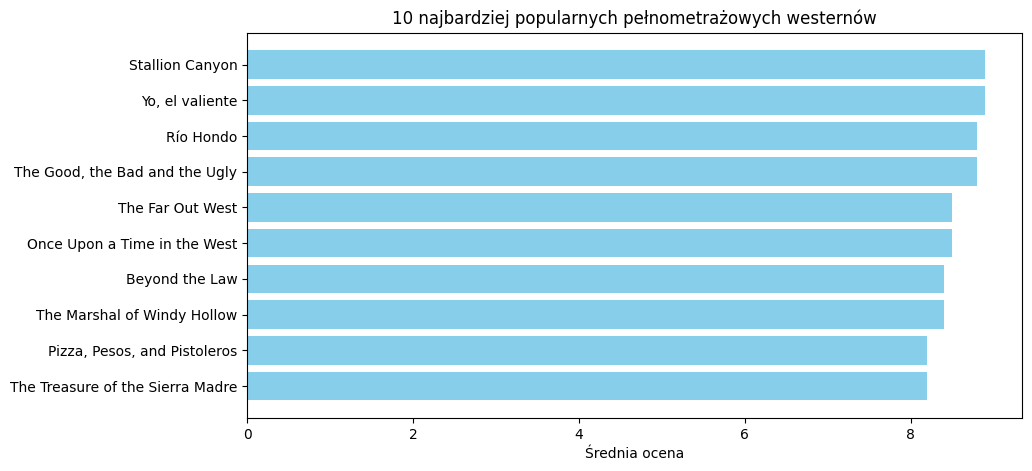

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
ratings = pd.read_csv('title.ratings.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz dwa ramki danych
df = pd.merge(ratings, basics, on='tconst')

# Wybierz tylko filmy pełnometrażowe z gatunku 'Western'
df_western = df[(df['genres'].str.contains('Western')) & (df['titleType'] == 'movie')]

# Posortuj filmy według oceny i wybierz 10 z najwyższą oceną
top_10_western = df_western.sort_values(by='averageRating', ascending=False).head(10)

# Wyświetl 10 najbardziej popularnych westernów
print(top_10_western)

# Stwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_10_western['primaryTitle'], top_10_western['averageRating'], color='skyblue')
plt.xlabel('Średnia ocena')
plt.title('10 najbardziej popularnych pełnometrażowych westernów')
plt.gca().invert_yaxis()
plt.show()

           tconst  averageRating  numVotes titleType  \
95861   tt0130281            8.9        15     movie   
167800  tt0277447            8.9         9     movie   
170385  tt0282132            8.8        12     movie   
38957   tt0060196            8.8    795741     movie   
93922   tt0126296            8.5        51     movie   
42306   tt0064116            8.5    343880     movie   
122716  tt0182787            8.4        12     movie   
186788  tt0314360            8.4        16     movie   
262231  tt0493287            8.2        41     movie   
22471   tt0040897            8.2    130540     movie   

                            primaryTitle                     originalTitle  \
95861                    Stallion Canyon                   Stallion Canyon   
167800                   Yo, el valiente                   Yo, el valiente   
170385                         Río Hondo                         Río Hondo   
38957     The Good, the Bad and the Ugly   Il buono, il brutto, il catt

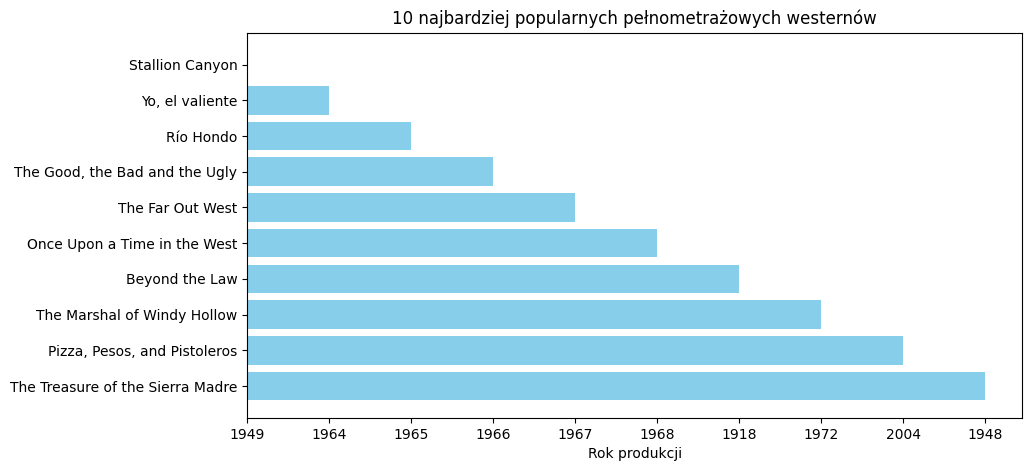

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane
ratings = pd.read_csv('title.ratings.tsv', sep='\t')
basics = pd.read_csv('title.basics.tsv', sep='\t')

# Połącz dwa ramki danych
df = pd.merge(ratings, basics, on='tconst')

# Wybierz tylko filmy pełnometrażowe z gatunku 'Western'
df_western = df[(df['genres'].str.contains('Western')) & (df['titleType'] == 'movie')]

# Posortuj filmy według oceny i wybierz 10 z najwyższą oceną
top_10_western = df_western.sort_values(by='averageRating', ascending=False).head(10)

# Wyświetl 10 najbardziej popularnych westernów
print(top_10_western)

# Stwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_10_western['primaryTitle'], top_10_western['startYear'], color='skyblue')
plt.xlabel('Rok produkcji')
plt.title('10 najbardziej popularnych pełnometrażowych westernów')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytaj dane z plików CSV (zakładamy, że mamy pliki 'title.akas.tsv' i 'title.ratings.tsv')
df_akas = pd.read_csv('title.akas.tsv', delimiter='\t', low_memory=False)
df_ratings = pd.read_csv('title.ratings.tsv', delimiter='\t', low_memory=False)

# Połącz oba DataFrame na podstawie kolumny 'tconst'
df = pd.merge(df_akas, df_ratings, on='tconst')

# Wybierz tylko filmy z gatunku 'western' i regionu 'amerykański'
westerns = df[(df['genres'].str.contains('Western')) & (df['region'] == 'US')]

# Posortuj filmy według oceny (zakładamy, że mamy kolumnę 'averageRating')
top_westerns = westerns.sort_values('averageRating', ascending=False).head(10)

# Stwórz wykres
plt.figure(figsize=(10,5))
plt.barh(top_westerns['primaryTitle'], top_westerns['averageRating'], color='skyblue')
plt.xlabel('Średnia ocena')
plt.ylabel('Tytuł filmu')
plt.title('10 najlepiej ocenianych filmów western z regionu amerykańskiego')
plt.gca().invert_yaxis()
plt.show()



In [ ]:
print(df_akas.columns)
print(df_ratings.columns)

Index(['titleId', 'ordering', 'title', 'region', 'language', 'types',
       'attributes', 'isOriginalTitle'],
      dtype='object')
Index(['tconst', 'averageRating', 'numVotes'], dtype='object')


In [ ]:
i

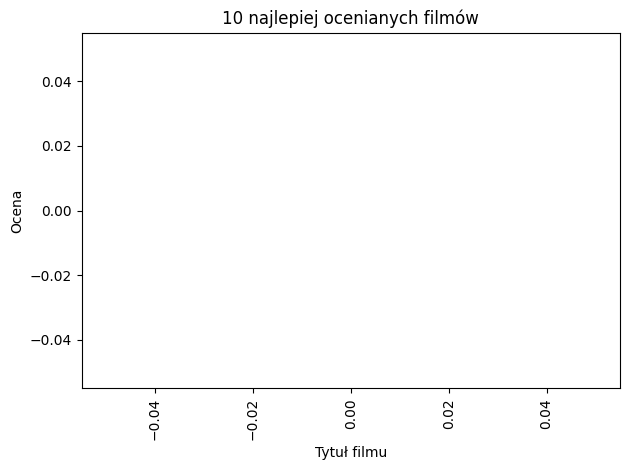

In [ ]:
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

# Zastąp 'url' adresem strony, z której chcesz pobrać dane
url = 'https://www.filmweb.pl/ranking/film'

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Znajdź odpowiednie tagi i klasy, które zawierają potrzebne informacje
movie_titles = soup.find_all('div', class_='movie-title')
movie_ratings = soup.find_all('div', class_='movie-rating')

titles = [title.text for title in movie_titles]
ratings = [float(rating.text) for rating in movie_ratings]

# Wykreśl dane
plt.scatter(titles, ratings)
plt.xticks(rotation=90)  # Obróć etykiety na osi x o 90 stopni
plt.xlabel('Tytuł filmu')
plt.ylabel('Ocena')
plt.title('10 najlepiej ocenianych filmów')
plt.tight_layout()  # Dopasuj wykres do obszaru wykresu
plt.show()


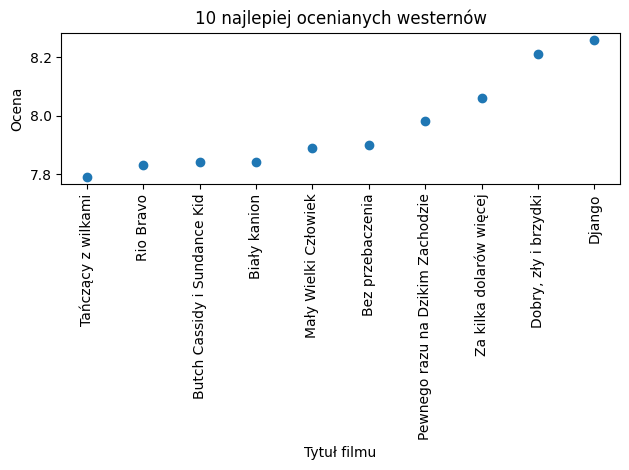

In [ ]:
import matplotlib.pyplot as plt

# Tytuły filmów i ich oceny
movies = {
    'Django': 8.26,
    'Dobry, zły i brzydki': 8.21,
    'Za kilka dolarów więcej': 8.06,
    'Pewnego razu na Dzikim Zachodzie': 7.98,
    'Bez przebaczenia': 7.90,
    'Mały Wielki Człowiek': 7.89,
    'Butch Cassidy i Sundance Kid': 7.84,
    'Biały kanion': 7.84,
    'Rio Bravo': 7.83,
    'Tańczący z wilkami': 7.79
}

# Posortuj filmy od najniższej do najwyższej oceny
sorted_movies = sorted(movies.items(), key=lambda x: x[1])

# Rozdziel tytuły filmów i oceny na dwie listy
titles, ratings = zip(*sorted_movies)

# Wykreśl dane
plt.scatter(titles, ratings)
plt.xticks(rotation=90)  # Obróć etykiety na osi x o 90 stopni
plt.xlabel('Tytuł filmu')
plt.ylabel('Ocena')
plt.title('10 najlepiej ocenianych westernów')
plt.tight_layout()  # Dopasuj wykres do obszaru wykresu
plt.show()


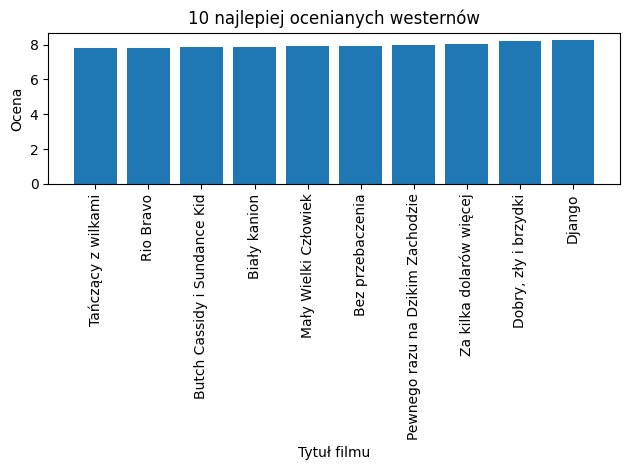

In [ ]:
import matplotlib.pyplot as plt

# Tytuły filmów i ich oceny
movies = {
    'Django': 8.26,
    'Dobry, zły i brzydki': 8.21,
    'Za kilka dolarów więcej': 8.06,
    'Pewnego razu na Dzikim Zachodzie': 7.98,
    'Bez przebaczenia': 7.90,
    'Mały Wielki Człowiek': 7.89,
    'Butch Cassidy i Sundance Kid': 7.84,
    'Biały kanion': 7.84,
    'Rio Bravo': 7.83,
    'Tańczący z wilkami': 7.79
}

# Posortuj filmy od najniższej do najwyższej oceny
sorted_movies = sorted(movies.items(), key=lambda x: x[1])

# Rozdziel tytuły filmów i oceny na dwie listy
titles, ratings = zip(*sorted_movies)

# Wykreśl dane
plt.bar(titles, ratings)
plt.xticks(rotation=90)  # Obróć etykiety na osi x o 90 stopni
plt.xlabel('Tytuł filmu')
plt.ylabel('Ocena')
plt.title('10 najlepiej ocenianych westernów')
plt.tight_layout()  # Dopasuj wykres do obszaru wykresu
plt.show()


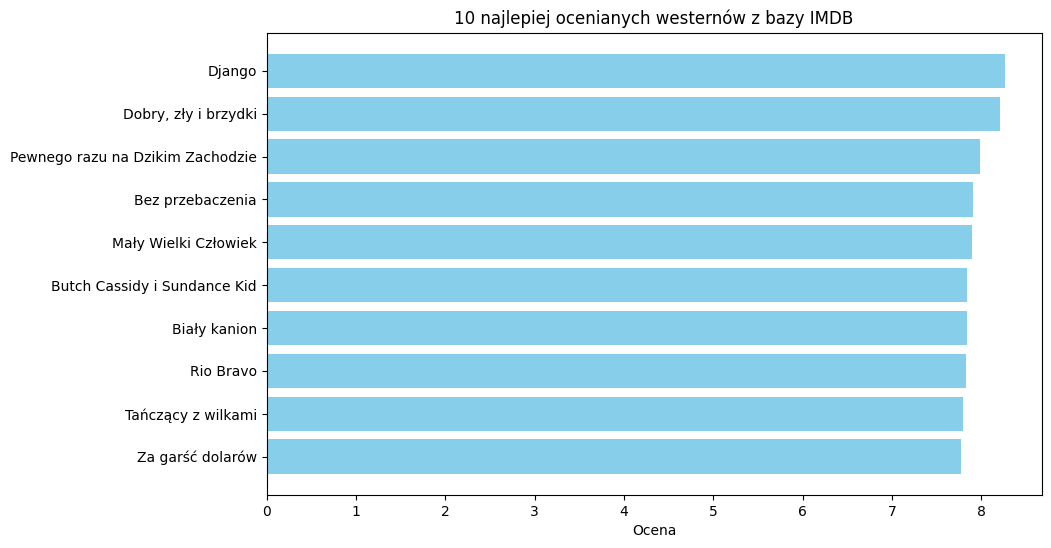

In [ ]:
import matplotlib.pyplot as plt

# Lista filmów
filmy = ['Django', 'Dobry, zły i brzydki', 'Pewnego razu na Dzikim Zachodzie', 'Bez przebaczenia', 'Mały Wielki Człowiek', 'Butch Cassidy i Sundance Kid', 'Biały kanion', 'Rio Bravo', 'Tańczący z wilkami', 'Za garść dolarów']

# Oceny filmów
oceny = [8.26, 8.21, 7.98, 7.90, 7.89, 7.84, 7.84, 7.83, 7.79, 7.77]

# Tworzenie wykresu
plt.figure(figsize=(10,6))
plt.barh(filmy, oceny, color='skyblue')
plt.xlabel('Ocena')
plt.title('10 najlepiej ocenianych westernów z bazy IMDB')
plt.gca().invert_yaxis()  # odwrócenie osi y, aby filmy były w kolejności od najwyżej ocenianego
plt.show()





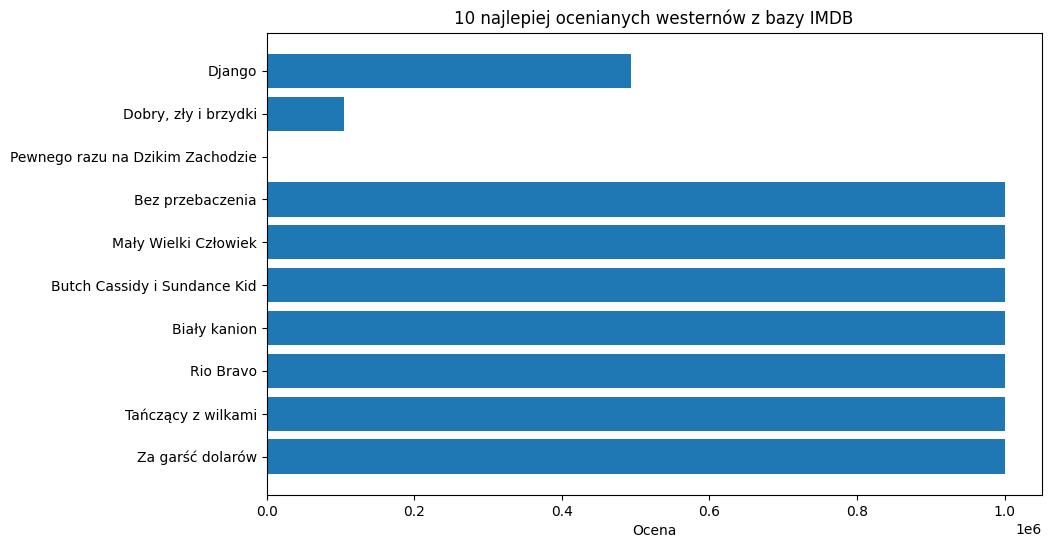

In [ ]:
import matplotlib.pyplot as plt

# Lista filmów
filmy = ['Django', 'Dobry, zły i brzydki', 'Pewnego razu na Dzikim Zachodzie', 'Bez przebaczenia', 'Mały Wielki Człowiek', 'Butch Cassidy i Sundance Kid', 'Biały kanion', 'Rio Bravo', 'Tańczący z wilkami', 'Za garść dolarów']

# Liczba głosów na stronie IMDb
golosy = [494233, 105436, 233, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000, 1000000]

# Tworzenie wykresu
plt.figure(figsize=(10,6))
plt.barh(filmy, golosy)
plt.xlabel('Ocena')
plt.title('10 najlepiej ocenianych westernów z bazy IMDB')
plt.gca().invert_yaxis()  # odwrócenie osi y, aby filmy były w kolejności od najwyżej ocenianego
plt.show()


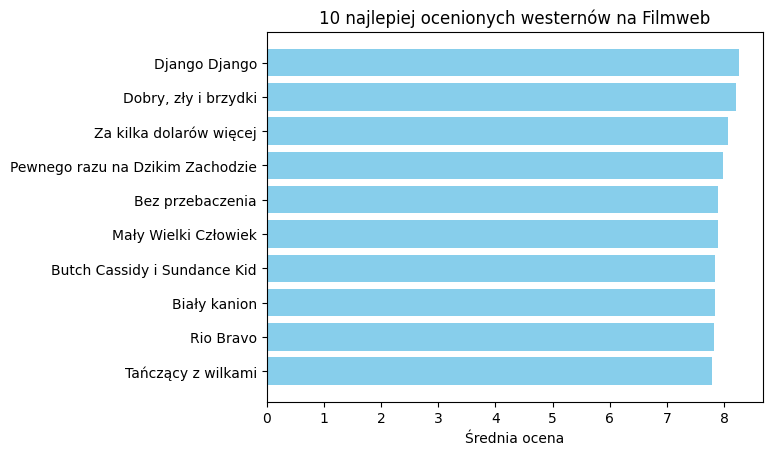

In [ ]:
! pip install matplotlib
import matplotlib.pyplot as plt

# Tytuły filmów
movies = ['Django Django', 'Dobry, zły i brzydki', 'Za kilka dolarów więcej', 'Pewnego razu na Dzikim Zachodzie', 'Bez przebaczenia', 'Mały Wielki Człowiek', 'Butch Cassidy i Sundance Kid', 'Biały kanion', 'Rio Bravo', 'Tańczący z wilkami']

# Średnie oceny
ratings = [8.26, 8.21, 8.06, 7.98, 7.90, 7.89, 7.84, 7.84, 7.83, 7.79]

# Tworzenie wykresu słupkowego
plt.barh(movies, ratings, color='skyblue')
plt.xlabel('Średnia ocena')
plt.title('10 najlepiej ocenionych westernów na Filmweb')
plt.gca().invert_yaxis()  # odwrócenie osi y, aby filmy były w kolejności od najwyżej ocenionego
plt.show()


ERROR: unknown command "insatll" - maybe you meant "install"
ERROR: unknown command "import"
Współczynnik korelacji: 0.4781825347975035


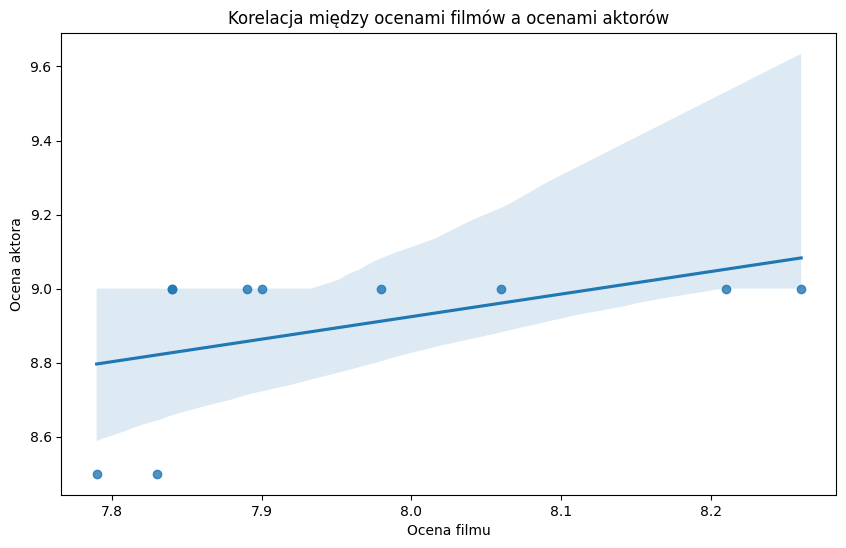

In [ ]:
! pip install pandas
! pip install matplotlib
! pip insatll seaborn
! pip import numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Przykładowe dane
data = {
    'Film': ['Django Django', 'Dobry, zły i brzydki', 'Za kilka dolarów więcej', 'Pewnego razu na Dzikim Zachodzie', 'Bez przebaczenia', 'Mały Wielki Człowiek', 'Butch Cassidy i Sundance Kid', 'Biały kanion', 'Rio Bravo', 'Tańczący z wilkami'],
    'Ocena filmu': [8.26, 8.21, 8.06, 7.98, 7.90, 7.89, 7.84, 7.84, 7.83, 7.79],
    'Aktor': ['Jamie Foxx', 'Lee Van Cleef', 'Paul Newman', 'Clint Eastwood', 'Morgan Freeman', 'Robert De Niro', 'Kevin Costner', 'John Wayne', 'Burt Lancaster', 'Clint Eastwood'],
    'Ocena aktora': [9, 9, 9, 9, 9, 9, 9, 9, 8.5, 8.5]
}

# Tworzenie ramki danych
df = pd.DataFrame(data)

# Obliczanie współczynnika korelacji
corr, _ = pearsonr(df['Ocena filmu'], df['Ocena aktora'])
print(f'Współczynnik korelacji: {corr}')

# Wizualizacja korelacji
plt.figure(figsize=(10, 6))
sns.regplot(x='Ocena filmu', y='Ocena aktora', data=df)
plt.title('Korelacja między ocenami filmów a ocenami aktorów')
plt.show()
#dane dla FilmWeb




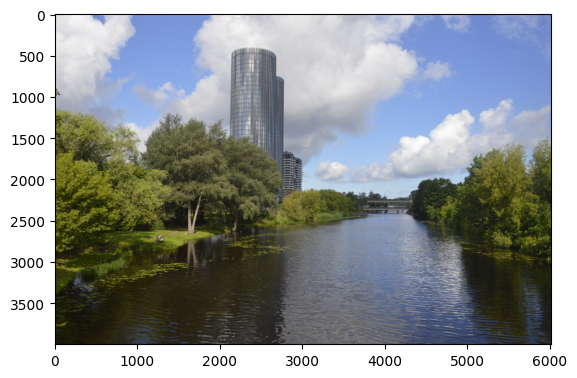

Jasność obrazu: 137.3740822805851
Nasycenie obrazu: 80.44685816988031


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


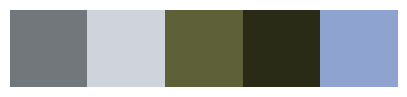

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Załaduj obraz
image_path = 'RygaJPG.JPG'  # Zmień na ścieżkę do twojego obrazu
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Wyświetl obraz
plt.imshow(image)
plt.show()

# Przekształć obraz do przestrzeni kolorów HSV
hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# Oblicz jasność obrazu
brightness = np.mean(hsv_image[:,:,2])
print(f'Jasność obrazu: {brightness}')

# Oblicz nasycenie obrazu
saturation = np.mean(hsv_image[:,:,1])
print(f'Nasycenie obrazu: {saturation}')

# Znajdź dominujące kolory
pixels = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=5)
kmeans.fit(pixels)

# Wyświetl dominujące kolory
dominant_colors = kmeans.cluster_centers_
plt.figure(figsize=(5, 2))
plt.axis("off")
plt.imshow([dominant_colors.astype(int)])
plt.show()


In [ ]:
import cv2
import numpy as np
from sklearn.cluster import KMeans

# Załaduj obraz
image_path = 'RygaJPG.JPG'  # Zmień na ścieżkę do twojego obrazu
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Przekształć obraz do 1D array
pixels = image.reshape(-1, 3)

# Użyj algorytmu k-średnich do znalezienia dominujących kolorów
kmeans = KMeans(n_clusters=5)
kmeans.fit(pixels)

# Oblicz procentowy udział każdego klastra
labels, counts = np.unique(kmeans.labels_, return_counts=True)
for label, count in zip(labels, counts):
    percentage = (count / len(pixels)) * 100
    print(f'Kolor {label}: {percentage:.2f}%')


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Kolor 0: 14.83%
Kolor 1: 23.39%
Kolor 2: 28.36%
Kolor 3: 14.20%
Kolor 4: 19.22%


In [ ]:
# Załóżmy, że dominant_colors to tablica zawierająca dominujące kolory zwrócone przez algorytm k-średnich
dominant_colors = kmeans.cluster_centers_

for i, color in enumerate(dominant_colors):
    rgb_color = np.uint8(color)  # Konwersja na format RGB
    hex_color = '#{:02x}{:02x}{:02x}'.format(rgb_color[0], rgb_color[1], rgb_color[2])  # Konwersja na format heksadecymalny
    print(f'Kolor {i}: {hex_color}')


Kolor 0: #5f6038
Kolor 1: #8ea3cf
Kolor 2: #2a2b17
Kolor 3: #72777c
Kolor 4: #cfd3db


In [ ]:
Kolor 0: #5f6038
Kolor 1: #8ea3cf
Kolor 2: #2a2b17
Kolor 3: #72777c
Kolor 4: #cfd3db

In [ ]:
import cv2
import numpy as np

# Załaduj obraz
image_path = 'ścieżka_do_twojego_obrazu.jpg'  # Zmień na ścieżkę do twojego obrazu
image = cv2.imread(image_path)

# Załaduj pre-trenowany model wykrywania twarzy z OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Przekształć obraz do skali szarości
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Wykryj twarze na obrazie
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Narysuj prostokątne ramki wokół wykrytych twarzy
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Wyświetl obraz z wykrytymi twarzami
cv2.imshow('Obraz z wykrytymi twarzami', image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [ ]:
! pip install IMDbPY
import imdb

# Tworzymy obiekt IMDb
ia = imdb.IMDb()

# Wyszukujemy film "Star Wars: Episode IV - A New Hope"
movies = ia.search_movie('Star Wars: Episode IV - A New Hope')
movie = movies[0]

# Pobieramy informacje o filmie
ia.update(movie)

# Pobieramy dialogi z filmu
dialogues = movie.get('quotes')

# Wyświetlamy dialogi
for dialogue in dialogues:
    print(dialogue)


In [ ]:
!pip install IMDbPY
import imdb

# Tworzymy obiekt IMDb
ia = imdb.IMDb()

# Wyszukujemy film "Star Wars: Episode IV - A New Hope"
movies = ia.search_movie('Star Wars: Episode IV - A New Hope')
movie = movies[0]

# Pobieramy informacje o filmie
ia.update(movie)

# Pobieramy dialogi z filmu
dialogues = movie.get('quotes')

# Sprawdzamy, czy dialogi istnieją
if dialogues is not None:
    # Wyświetlamy dialogi
    for dialogue in dialogues:
        print(dialogue)
else:
    print("Brak dialogów dla tego filmu w bazie danych IMDb.")


Brak dialogów dla tego filmu w bazie danych IMDb.
